In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from scipy.signal import fftconvolve
from numba import njit
from tqdm import tqdm
from joblib import Parallel, delayed

In [2]:
plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['image.origin'] = "lower"
plt.rcParams['image.cmap'] = 'magma'

In [3]:
class NoiseModel:
    def __init__(
        self,
        image: np.ndarray | None = None,
        rms: np.ndarray | None = None,
        image_conversion_factor: float = 1.0,
        rms_conversion_factor: float = 1.0,
        uncorrelated = False
    ) -> None:

        self.image = image
        self.rms = rms
        self.image_conversion_factor = image_conversion_factor
        self.rms_conversion_factor = rms_conversion_factor
        self.uncorrelated = uncorrelated

        self.noise_square = None
        self.noise_covariance = None
        self.poisson_image = None
        self.ac = None
        self.kernel = None

    def find_noise_square(self,
                          box_size: int = 100,
                          image: np.ndarray | None = None
                          ) -> None:
        """
        Find a sourceless square from an image and store it.

        Parameters
        ----------
        box_size: int, optional
            Size of the noise square
        image: np.ndarray | None, optional
            Image from which a noise square is extracted
            If None the class image is used
        """
        image = self.image if image is None else image

        ny, nx = image.shape

        best_std = np.inf
        best_square = None

        # define smaller square size and step
        step = box_size  # or smaller (e.g. box_size // 2 for overlap)

        for y in range(0, ny - box_size + 1, step):
            for x in range(0, nx - box_size + 1, step):

                square = image[y:y+box_size, x:x+box_size]

                # compute statistics for this square
                local_mean = np.mean(square)
                local_var = np.var(square)
                local_std = np.sqrt(local_var)

                signal_threshold = np.percentile(square, 10)
                nonzero_fraction = np.count_nonzero(square) / square.size

                # reject "bad" squares
                # if local_mean >= signal_threshold:
                #     continue
                if nonzero_fraction < 0.5:
                    continue

                # keep the best (lowest noise)
                if local_std < best_std:
                    best_std = local_std
                    best_square = square

        # fallback if nothing found
        if best_square is None:
            raise ValueError("No suitable noise square found")

        self.noise_square = best_square

    def set_noise_square(self, noise_square):
        self.noise_square = noise_square

    def set_noise_covariance(self, maxlag: int) -> None:
        """
        Extract a fixed-size cutout centered on (cy, cx).
        Pads with zeros when the cutout extends beyond the image.

        Parameters
        ----------
        maxlag: int
            Maximum pixel difference where the pixel are still correlated
        """

        image = self.noise_square * self.image_conversion_factor
        self.noise_covariance = self._covariance_fft2d(image, maxlag)

    def _covariance_fft2d(self, noise_image: np.ndarray, maxlag: int) -> np.ndarray:
        """
        Calculate the local covariance matrix from the noise square

        Parameters
        ----------
        noise_image: np.ndarray
            Description of param1
        maxlag: int
            Maximum pixel difference where the pixel are still correlated

        Returns
        -------
        np.ndarray
            Local covariance matrix
        """

        img = noise_image.copy()
        h, w = img.shape
        img -= np.mean(img)

        self.ac = fftconvolve(img, img[::-1, ::-1], mode="same")
        self.ac /= (h * w)

        cy, cx = h // 2, w // 2

        return self.ac[
            cy - maxlag: cy + maxlag + 1,
            cx - maxlag: cx + maxlag + 1,
        ]
    def calc_error(self, weight, xc, yc, size):
        if self.rms is None:
            return self.background_error(weight)
        else:
            return self.rms_error(weight, xc, yc, size)

    def background_error(self, weight):
        if self.uncorrelated:
            negative_pixels = self.noise_square[self.noise_square < 0]

            background_variance = (
                np.sum(negative_pixels**2) / len(negative_pixels)
            ) * self.image_conversion_factor**2
            return background_variance * np.sum(weight**2)
        autocorr_weight = fftconvolve(weight, weight[::-1, ::-1], mode='same')
        noise_covariance = self.noise_covariance[:weight.shape[0], :weight.shape[1]]
        return np.sum(noise_covariance * autocorr_weight)

    def rms_error(self, weight, xc, yc, size):
        if self.kernel is None:
            self.kernel = self.ac / np.max(self.ac)

        rms_cutout, _ = padded_cutout_with_center(self.rms, xc, yc, size)
        rms_cutout = rms_cutout[:weight.shape[0], :weight.shape[1]]
        weight_prime = rms_cutout * weight * self.rms_conversion_factor
        if self.uncorrelated:
            return np.sum(weight_prime * weight_prime)
        conv = fftconvolve(weight_prime, self.kernel, mode='same')
        return np.sum(weight_prime * conv)

In [183]:
@njit
def gaussian_weight(height: int, width: int, xc: float = 0, yc: float = 0, sigma: float = 1) -> np.ndarray:
    """
    Calculate Gaussian weight function

    Parameters
    ----------
    height: int
        Height of the weight function in pixels
    width: int
        Width of the weight function in pixels
    xc: float, optional
        x coordinate of the center of the weight function in pixels
    yc: float, optional
        y coordinate of the center of the weight function in pixels
    sigma: float, optional
        Scale parameter of the weight function

    Returns
    -------
    np.ndarray:
        Weight function
    """

    # Create an array for the x and y direction
    x = np.arange(width)
    y = np.arange(height)

    # Calculate the Gaussian in the x and y direction
    gx = np.exp(-0.5 * ((x - xc) / sigma) ** 2)
    gy = np.exp(-0.5 * ((y - yc) / sigma) ** 2)

    # Combining the x and y direction to make a 2D Gaussian
    return gy[:, None] * gx[None, :]

def padded_cutout_with_center(image: np.ndarray, cx: float, cy: float, size: int) -> tuple[np.ndarray, tuple[float, float]]:
    """
    Extract a fixed-size cutout centered on (cy, cx).
    Pads with zeros when the cutout extends beyond the image.

    Parameters
    ----------
    image: np.ndarray
        Image from which the cutout is extracted
    cx: float
        x coordinate of the center of the cutout in the origal image
    cy: float
        y coordinate of the center of the cutout in the origal image
    size: int
        Size of the cutout

    Returns
    -------
    np.ndarray:
        Cutout
    tuple[float, float]:
        Center corresponding to (cx, cy) in the cutout

    Raises
    ------
    ValueError
        Description of when this error is raised
    """

    h, w = image.shape
    half = size // 2

    # Integer anchor
    iy = np.int64(np.floor(cy))
    ix = np.int64(np.floor(cx))

    # Desired bounds in image coordinates
    y0 = iy - half
    x0 = ix - half
    y1 = y0 + size
    x1 = x0 + size

    # Overlap with image
    iy0 = max(0, y0)
    ix0 = max(0, x0)
    iy1 = min(h, y1)
    ix1 = min(w, x1)

    # Corresponding region in cutout coordinates
    cy0 = iy0 - y0
    cx0 = ix0 - x0
    cy1 = cy0 + (iy1 - iy0)
    cx1 = cx0 + (ix1 - ix0)

    # Allocate cutout
    cutout = np.zeros((size, size))

    # Insert image data
    cutout[cy0:cy1, cx0:cx1] = image[iy0:iy1, ix0:ix1]

    # Center in cutout coordinates
    cy_c = cy - y0
    cx_c = cx - x0

    return cutout, (cx_c, cy_c)

def gaussian_2d(x, y, x0=0, y0=0, sigma_x=1, sigma_y=1, A=1):
    return A * np.exp(
        -0.5*(((x-x0) / sigma_x ) ** 2 +
          ((y-y0) / sigma_y)**2)
    )


def fourier_gaussian_2d(x, y, sigma_x=1, sigma_y=1, A=1):
    return A * 2*np.pi * sigma_y * sigma_x* np.exp(
        -0.5* ((sigma_x * x)**2 + (sigma_y * y)**2)
    )

@njit
def bilinear_shift(weight: np.ndarray, dx: float, dy: float) -> np.ndarray:
    """
    Creates a shifted version of the weight function
    that captures the bilinear interpolation

    Parameters
    ----------
    weight: np.ndarray
        Weight function that needs to be shifted
    dx: float
        Fractional part of the x coordinate (0 <= dx <= 1)
    dy: float
        Fractional part of the y coordinate (0 <= dy <= 1)

    Returns
    -------
    np.ndarray
        Bilinear interpolated weight function

    Raises
    ------
    ValueError
        Description of when this error is raised
    """
    W_shifted = (1 - dx) * (1 - dy) * weight[:-1, :-1] \
        + dx * (1 - dy) * weight[:-1, 1:] \
        + (1 - dx) * dy * weight[1:, :-1] \
        + dx * dy * weight[1:, 1:]
    return W_shifted

def flux(image, center, psf:np.ndarray, weight_sizes, noise_model=None, cutout_size=128, eps=1e-8):
    ky = np.fft.fftfreq(cutout_size) * 2*np.pi
    kx = np.fft.rfftfreq(cutout_size) * 2*np.pi

    KX, KY = np.meshgrid(kx, ky)


    psf_padded, _ = padded_cutout_with_center(psf, psf.shape[0]/2, psf.shape[1]/2, cutout_size)
    FT_psf = np.fft.rfft2(psf_padded[::-1, ::-1])
    psf_prefactor = np.conj(FT_psf) / (np.abs(FT_psf)**2 + eps)

    is_scalar_center = np.ndim(center) == 1
    is_scalar_weight = np.ndim(weight_sizes) == 0

    centers = np.atleast_2d(center)          # (Nc, 2)
    weight_sizes = np.atleast_1d(weight_sizes)
    Nc = centers.shape[0]
    Nw = len(weight_sizes)

    if is_scalar_center and is_scalar_weight:
        x_c, y_c = center

        FT_weight = fourier_gaussian_2d(KX, KY, weight_sizes[0], weight_sizes[0])
        weight_rescale = np.fft.irfft2(psf_prefactor * FT_weight)

        cutout, (cx_cut, cy_cut) = padded_cutout_with_center(
            image, x_c, y_c, cutout_size
        )

        dx = cx_cut - int(cx_cut)
        dy = cy_cut - int(cy_cut)

        W_shifted = bilinear_shift(weight_rescale, dx, dy)
        cutout_trim = cutout[:W_shifted.shape[0], :W_shifted.shape[1]]

        fluxes = np.sum(W_shifted * cutout_trim)

        weight_for_variance = weight_rescale if noise_model.rms is None else W_shifted
        variances = noise_model.calc_error(weight_for_variance, x_c, y_c, cutout_size)

    elif not is_scalar_center and is_scalar_weight:

        FT_weight = fourier_gaussian_2d(KX, KY, weight_sizes[0], weight_sizes[0])
        weight_rescale = np.fft.irfft2(psf_prefactor * FT_weight)

        fluxes = np.empty(Nc)
        variances = None if noise_model is None else np.empty(Nc)

        for c in range(Nc):
            x_c, y_c = centers[c]

            cutout, (cx_cut, cy_cut) = padded_cutout_with_center(
                image, x_c, y_c, cutout_size
            )

            dx = cx_cut - int(cx_cut)
            dy = cy_cut - int(cy_cut)

            W_shifted = bilinear_shift(weight_rescale, dx, dy)
            cutout_trim = cutout[:W_shifted.shape[0], :W_shifted.shape[1]]

            fluxes[c] = np.sum(W_shifted * cutout_trim)

            if noise_model is not None:
                weight_for_variance = weight_rescale if noise_model.rms is None else W_shifted
                variances[c] = noise_model.calc_error(weight_for_variance, x_c, y_c, cutout_size)

    elif is_scalar_center and not is_scalar_weight:

        x_c, y_c = center

        cutout, (cx_cut, cy_cut) = padded_cutout_with_center(
            image, x_c, y_c, cutout_size
        )

        dx = cx_cut - int(cx_cut)
        dy = cy_cut - int(cy_cut)

        fluxes = np.empty(Nw)
        variances = None if noise_model is None else np.empty(Nw)

        sorted_idx = np.argsort(weight_sizes)
        last_weight_size = None
        for i in sorted_idx:
            weight_size = weight_sizes[i]
            if weight_size != last_weight_size:
                FT_weight = fourier_gaussian_2d(KX, KY, weight_size, weight_size)
                weight_rescale = np.fft.irfft2(psf_prefactor * FT_weight)
                last_weight_size = weight_size

            W_shifted = bilinear_shift(weight_rescale, dx, dy)
            cutout_trim = cutout[:W_shifted.shape[0], :W_shifted.shape[1]]

            fluxes[i] = np.sum(W_shifted * cutout_trim)

            if noise_model is not None:
                weight_for_variance = weight_rescale if noise_model.rms is None else W_shifted
                variances[i] = noise_model.calc_error(weight_for_variance, x_c, y_c, cutout_size)

    else:
        # Nc == Nw and paired 1-to-1
        N = len(weight_sizes)

        fluxes = np.empty(N)
        variances = None if noise_model is None else np.empty(N)

        sorted_idx = np.argsort(weight_sizes)
        last_weight_size = None
        for i in sorted_idx:
            x_c, y_c = centers[i]
            weight_size = weight_sizes[i]
            if weight_size != last_weight_size:
                FT_weight = fourier_gaussian_2d(KX, KY, weight_size, weight_size)
                weight_rescale = np.fft.irfft2(psf_prefactor * FT_weight)
                last_weight_size = weight_size

            # cutout depends only on center
            cutout, (cx_cut, cy_cut) = padded_cutout_with_center(
                image, x_c, y_c, cutout_size
            )

            dx = cx_cut - int(cx_cut)
            dy = cy_cut - int(cy_cut)

            W_shifted = bilinear_shift(weight_rescale, dx, dy)
            cutout_trim = cutout[:W_shifted.shape[0], :W_shifted.shape[1]]

            fluxes[i] = np.sum(W_shifted * cutout_trim)

            if noise_model is not None:
                weight_for_variance = weight_rescale if noise_model.rms is None else W_shifted
                variances[i] = noise_model.calc_error(weight_for_variance, x_c, y_c, cutout_size)

    return fluxes if noise_model is None else (fluxes, variances)

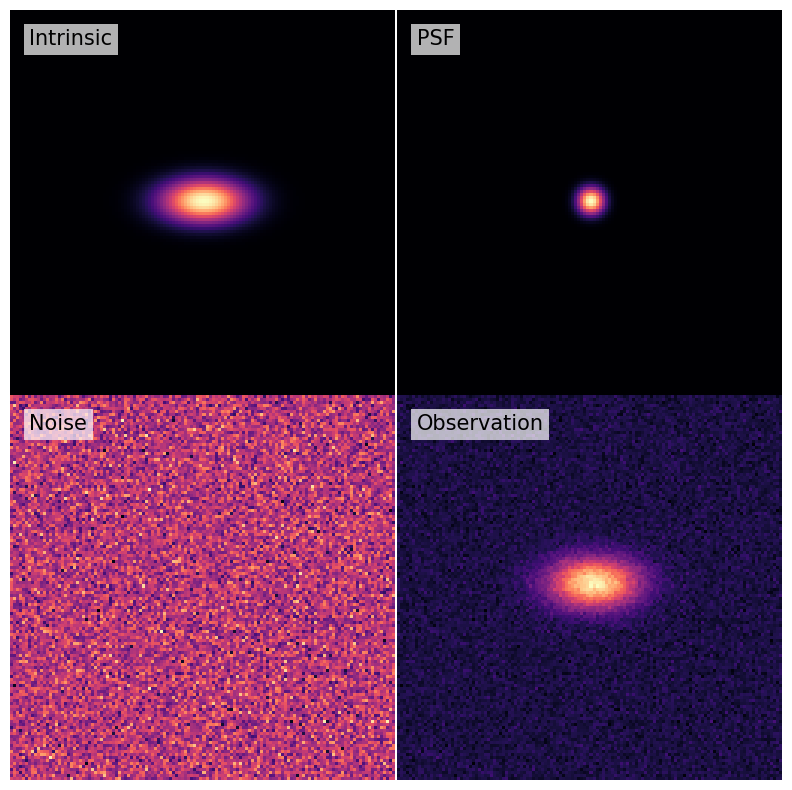

In [215]:
# grid
N= 128
x = np.arange(0, N, 1) - N/2
y = np.arange(0, N, 1) - N/2
X, Y = np.meshgrid(x, y)

star = gaussian_2d(X, Y, 0, 0, 10, 5, 100)
star /= np.sum(star)
star *= 1000
psf = gaussian_2d(X, Y, 0, 0, 3, 3, 1)
psf /= np.sum(psf)
observation = fftconvolve(star, psf, mode='same')
noise = np.random.normal(0, 0.1, (N, N))
observation += noise
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10, 10), gridspec_kw={'wspace': 0, 'hspace': 0})
axes = axes.flatten()
axes[0].imshow(star)
axes[0].text(0.05, 0.95, 'Intrinsic', transform=axes[0].transAxes,
                        ha='left', va='top', fontsize=15,
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
axes[1].imshow(psf)
axes[1].text(0.05, 0.95, 'PSF', transform=axes[1].transAxes,
                        ha='left', va='top', fontsize=15,
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
axes[2].imshow(noise)
axes[2].text(0.05, 0.95, 'Noise', transform=axes[2].transAxes,
                        ha='left', va='top', fontsize=15,
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
axes[3].imshow(observation)
axes[3].text(0.05, 0.95, 'Observation', transform=axes[3].transAxes,
                        ha='left', va='top', fontsize=15,
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
for ax in axes:
    ax.axis('off')

In [190]:
# grid
N= 128
x = np.arange(0, N, 1) - N/2
y = np.arange(0, N, 1) - N/2
X, Y = np.meshgrid(x, y)

star = gaussian_2d(X, Y, 0, 0, 10, 5, 100)
star /= np.sum(star)
star *= 1000
psf = gaussian_2d(X, Y, 0, 0, 3, 3, 1)
psf /= np.sum(psf)
observation = fftconvolve(star, psf, mode='same')
noise = np.random.normal(0, 0.1, (N, N))
observation += noise
weight_size = 10
weight = gaussian_2d(X, Y, 0, 0, weight_size, weight_size)
measured_accuracy = np.zeros_like(observation)
centers = np.empty((N,N, 2))
true_F = np.empty((N,N))
for i in np.int64(np.arange(0, N, 1) - N/2):
    for j in np.int64(np.arange(0, N, 1) - N/2):
        weight = gaussian_2d(X, Y, i, j, weight_size, weight_size)
        centers[i,j] = (i+N/2, j+N/2)
        true_F[i, j] = np.sum(weight*star)
centers = centers.reshape(-1, 2)
true_F = true_F.flatten()
measured_flux = flux(observation, centers, psf=psf, weight_sizes=weight_size, cutout_size=128, eps=1e-8)
measured_accuracy = np.abs((measured_flux - true_F) / true_F)

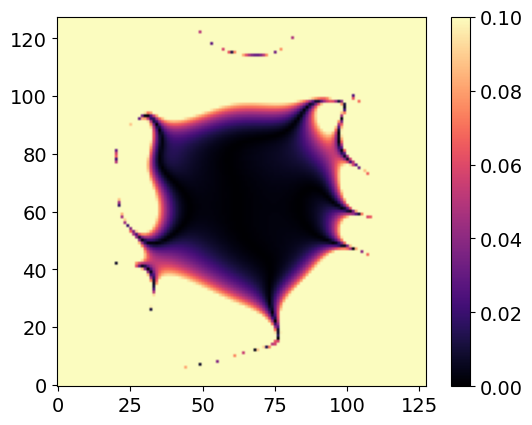

In [197]:
plt.imshow(np.fft.fftshift(measured_accuracy.reshape(128, 128)), origin='lower', vmin=0, vmax=.1)
plt.colorbar()
# plt.xlim(32, 128-32)
# plt.ylim(32, 128-32)
plt.show()

In [192]:
N= 128
x = np.arange(0, N, 1) - N/2
y = np.arange(0, N, 1) - N/2
X, Y = np.meshgrid(x, y)
star = gaussian_2d(X, Y, 0, 0, 10, 5, 100)
star /= np.sum(star)
star *= 1000
noise = np.random.normal(0, 0.1, (N, N))
N_points = 200
weight_sizes = np.linspace(0.1, 20, N_points)
psf_sizes = np.linspace(0.1, 20, N_points)
flux_err = np.zeros((N_points, N_points))

true_F = np.empty_like(weight_sizes)
for i, weight_size in enumerate(weight_sizes):
    weight = gaussian_2d(X, Y, 0, 0, weight_size, weight_size)
    true_F[i] = np.sum(weight*star)

for j, psf_size in enumerate(psf_sizes):
    psf = gaussian_2d(X, Y, 0, 0, psf_size, psf_size, 1)
    psf /= np.sum(psf)
    observation = fftconvolve(star, psf, mode='same')
    observation += noise
    measured_flux = flux(observation, (N/2, N/2), psf=psf, weight_sizes=weight_sizes, cutout_size=128, eps=1e-8)
    flux_err[:,j] = np.abs((measured_flux - true_F) / true_F)

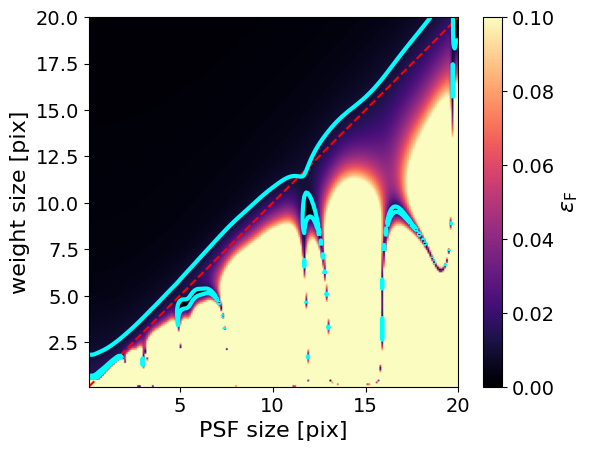

In [193]:
X, Y = np.meshgrid(psf_sizes, weight_sizes)
plt.imshow(flux_err, origin='lower', extent=[psf_sizes[0], psf_sizes[-1], weight_sizes[0], weight_sizes[-1]], vmin=0, vmax=.1)
plt.plot([psf_sizes[0], psf_sizes[-1]], [psf_sizes[0], psf_sizes[-1]], 'r--')
plt.colorbar(label=r'$\epsilon_\mathrm{F}$')
plt.contour(
    X, Y, flux_err,
    levels=[0.01],
    colors='cyan',
    linewidths=3
)
plt.xlabel('PSF size [pix]')
plt.ylabel('weight size [pix]')
plt.show()

In [204]:
X, Y = np.meshgrid(x, y)
star = gaussian_2d(X, Y, 0, 0, 10, 5, 100)
star /= np.sum(star)
star *= 1000
actual_psf_size = 3
psf = gaussian_2d(X, Y, 0, 0, actual_psf_size, actual_psf_size, 1)
psf /= np.sum(psf)
observation = fftconvolve(star, psf, mode='same') + noise
weight_size = 10
weight = gaussian_2d(X, Y, 0, 0, weight_size, weight_size)
psf_sizes = np.linspace(.1, 20, 200)
flux_err = np.zeros((len(psf_sizes), len(psf_sizes)))
for i, true_psf_size in enumerate(psf_sizes):
    psf = gaussian_2d(X, Y, 0, 0, true_psf_size, true_psf_size, 1)
    psf /= np.sum(psf)
    observation = fftconvolve(star, psf, mode='same') + noise
    for j, psf_size in enumerate(psf_sizes):
        psf_new = gaussian_2d(X, Y, 0, 0, psf_size, psf_size)
        psf_new /= np.sum(psf_new)
        true_F = np.sum(weight*star)
        flux_err[i, j] =  np.abs((flux(observation, (N/2, N/2), psf=psf_new, weight_sizes=np.array([weight_size]), cutout_size=128, eps=1e-8)[0] - true_F) / true_F)

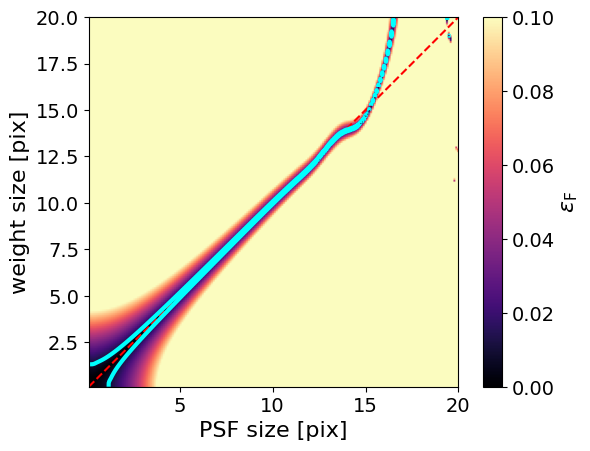

In [205]:
X, Y = np.meshgrid(psf_sizes, psf_sizes)
plt.imshow(flux_err, origin='lower', extent=[psf_sizes[0], psf_sizes[-1], psf_sizes[0], psf_sizes[-1]], vmin=0, vmax=.1)
plt.plot([psf_sizes[0], psf_sizes[-1]], [psf_sizes[0], psf_sizes[-1]], 'r--')
plt.colorbar(label=r'$\epsilon_\mathrm{F}$')
plt.contour(
    X, Y, flux_err,
    levels=[0.01],
    colors='cyan',
    linewidths=3
)
plt.xlabel('PSF size [pix]')
plt.ylabel('weight size [pix]')
plt.show()

In [156]:
def compute_psf_column(j, psf_size, weight_sizes, X, Y, star,
                       noise_images, noise_models, N_trials, N):

    psf = gaussian_2d(X, Y, 0, 0, psf_size, psf_size, 1)
    psf /= np.sum(psf)

    observation = fftconvolve(star, psf, mode='same')
    noisy_stack = observation[None, :, :] + noise_images

    col_fluxes = np.empty((N_trials, len(weight_sizes)))
    col_variances = np.empty((N_trials, len(weight_sizes)))

    for k in range(N_trials):
        f, v = flux(
            noisy_stack[k],
            (N/2, N/2),
            psf=psf,
            weight_sizes=weight_sizes,   # <- now vector
            noise_model=noise_models[k],
            cutout_size=128,
            eps=1e-8
        )
        col_fluxes[k] = f
        col_variances[k] = v

    std_flux = np.std(col_fluxes, axis=0)
    mean_sqrt_var = np.mean(np.sqrt(col_variances), axis=0)

    col = (mean_sqrt_var - std_flux) / std_flux

    return j, col

N_trials = 50
N= 128
noise_images = np.random.normal(0, .1, (N_trials, N, N))
noise_models = []
for k in range(N_trials):
    noise = NoiseModel(noise_images[k])
    noise.set_noise_square(noise_images[k])
    noise.set_noise_covariance(N//2)
    noise_models.append(noise)

x = np.arange(0, N, 1) - N/2
y = np.arange(0, N, 1) - N/2
X, Y = np.meshgrid(x, y)
star = gaussian_2d(X, Y, 0, 0, 10, 5, 100)
star /= np.sum(star)
star *= 1000
N_points = 100

weight_sizes = np.linspace(0.1, 20, N_points)
psf_sizes = np.linspace(0.1, 20, N_points)
sigma_err = np.zeros((N_points, N_points))

results = Parallel(n_jobs=-2)(
    delayed(compute_psf_column)(
        j, psf_sizes[j], weight_sizes, X, Y, star,
        noise_images, noise_models, N_trials, N
    )
    for j in range(N_points)
)

for j, col in results:
    sigma_err[:, j] = col

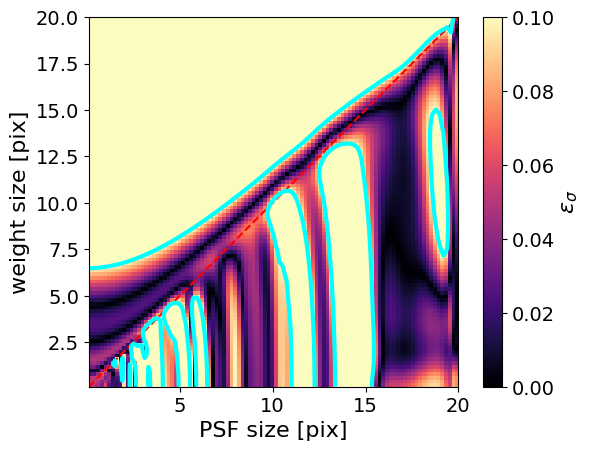

In [179]:
X, Y = np.meshgrid(psf_sizes, weight_sizes)
plt.imshow(np.abs(sigma_err), origin='lower', extent=[psf_sizes[0], psf_sizes[-1], weight_sizes[0], weight_sizes[-1]], vmin=0, vmax=.1)
plt.plot([psf_sizes[0], psf_sizes[-1]], [psf_sizes[0], psf_sizes[-1]], 'r--')
plt.colorbar(label=r'$\epsilon_{\sigma}$')
plt.contour(
    X, Y, np.abs(sigma_err),
    levels=[0.1],
    colors='cyan',
    linewidths=3
)
plt.xlabel('PSF size [pix]')
plt.ylabel('weight size [pix]')
plt.show()